# **Homework assignment 1**

**You need to first create a new empty database with a name (e.g., "MIMIC_IV_Demo"). Then populate the database by importing the following csv files from the MIMIC IV demo database: patients.csv, admissions.csv, diagnoses_icd.csv, and d_icd_diangoses.csv. You can use Azure Data Studio with the Import Wizard extension to create and load tables at the same time.**

In [ ]:
!pip install -U pip
!pip install pymssql

In [ ]:
import pymssql
import pandas as pd
from google.colab import userdata

#please use API keys for the 4 variables below
server = userdata.get('MIMIC_SERVER')
usr = userdata.get('MIMIC_USER')
pw = userdata.get('MIMIC_PW')
db= userdata.get('MIMIC_DB')

conn = pymssql.connect(
    server=server,
    user=usr,
    password=pw,
    database=db)
cursor = conn.cursor(as_dict=True)
sql='''SELECT did.long_title, COUNT(DISTINCT di.subject_id) AS subject_count
      FROM diagnoses_icd AS di
      LEFT JOIN d_icd_diagnoses AS did ON di.icd_code = did.icd_code AND di.icd_version = did.icd_version
      GROUP BY did.long_title
      HAVING COUNT(DISTINCT di.subject_id) >= 20
      ORDER BY subject_count DESC'''
cursor.execute(sql)

data=cursor.fetchall()
df=pd.DataFrame(data)

cursor.close()
conn.close()
print(df)


                                          long_title  subject_count
0                 Unspecified essential hypertension             41
1               Other and unspecified hyperlipidemia             34
2                  Acute kidney failure, unspecified             25
3                                Anemia, unspecified             25
4        Urinary tract infection, site not specified             22
5  Diabetes mellitus without mention of complicat...             21
6                        Hyperlipidemia, unspecified             21
7                               Obesity, unspecified             20
8                    Personal history of tobacco use             20
9                      Thrombocytopenia, unspecified             20


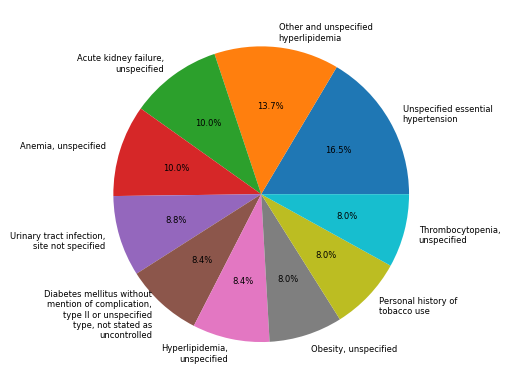

In [ ]:
import matplotlib.pyplot as plt
import textwrap
subject_counts = df['subject_count'].values.tolist()
diagnoses = df['long_title'].values.tolist()
diagnoses_wrapped = [textwrap.fill(label, 25) for label in diagnoses]

plt.pie(subject_counts, autopct='%1.1f%%',labels = diagnoses_wrapped, textprops={'fontsize': 6})
plt.show()

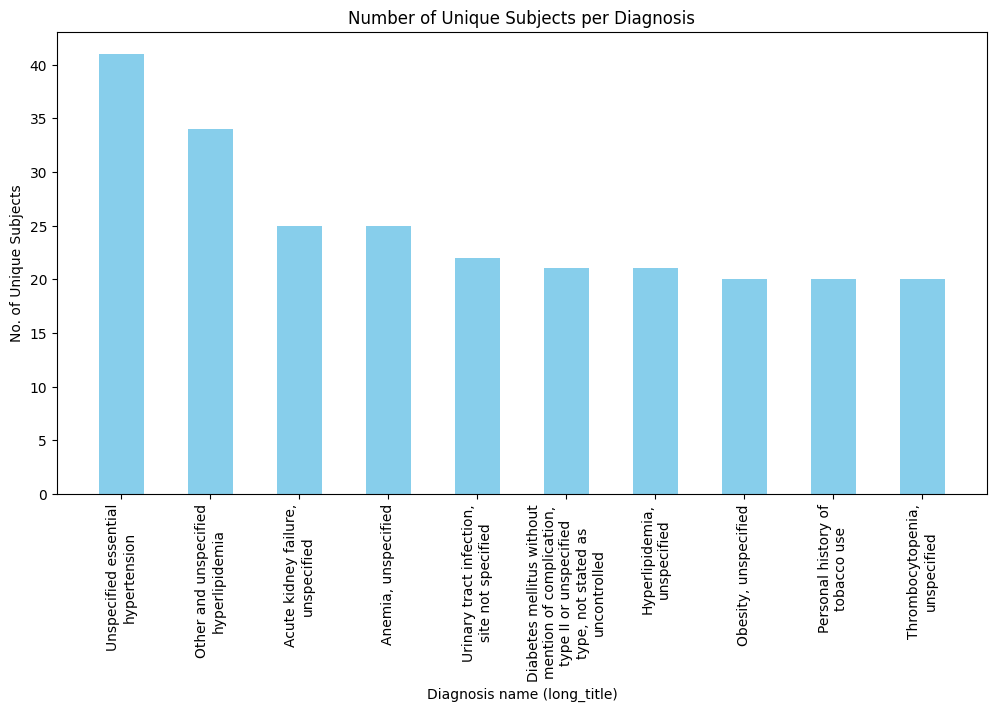

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(diagnoses_wrapped, subject_counts, color ='skyblue',
        width = 0.5)

plt.xlabel("Diagnosis name (long_title)")
plt.xticks(rotation='vertical') #'vertical'
plt.ylabel("No. of Unique Subjects")
plt.title("Number of Unique Subjects per Diagnosis")
plt.show()